In [1]:
# Credits: https://github.com/keras-team/keras/blob/master/examples/mnist_cnn.py


from __future__ import print_function
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K

batch_size = 128
num_classes = 10
epochs = 12

# input image dimensions
img_rows, img_cols = 28, 28

# the data, split between train and test sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

if K.image_data_format() == 'channels_first':
    x_train = x_train.reshape(x_train.shape[0], 1, img_rows, img_cols)
    x_test = x_test.reshape(x_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
    x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=input_shape))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=keras.optimizers.Adadelta(),
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(x_test, y_test))
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Using TensorFlow backend.
C:\Users\Deelip\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
C:\Users\Deelip\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
C:\Users\Deelip\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
C:\Users\Deelip\Anaconda3\lib\site-packages\tensorflow\python\framework\dtype

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


Train on 60000 samples, validate on 10000 samples
Epoch 1/12
60000/60000 [==============================] - 130s 2ms/step - loss: 0.2617 - accuracy: 0.9201 - val_loss: 0.0739 - val_accuracy: 0.9766
Epoch 2/12
60000/60000 [==============================] - 132s 2ms/step - loss: 0.0888 - accuracy: 0.9737 - val_loss: 0.0435 - val_accuracy: 0.9858
Epoch 3/12
60000/60000 [==============================] - 132s 2ms/step - loss: 0.0664 - accuracy: 0.9800 - val_loss: 0.0362 - val_accuracy: 0.9875
Epoch 4/12
60000/60000 [==============================] - 134s 2ms/step - loss: 0.0550 - accuracy: 0.9836 - val_loss: 0.0316 - val_accuracy: 0.9895
Epoch 5/12
60000/60000 [==============================] - 132s 2ms/step - loss: 0.0468 - accuracy: 0.9853 - val_loss: 0.0279 - val_accuracy: 0.9904
Epoch 6/12
60000/60000 [==============================] - 135s 2ms/step - loss: 0.0402 - accuracy: 0.9878 - val_loss: 0.0275 - val_accu

In [2]:
%matplotlib notebook
import matplotlib.pyplot as plt
import numpy as np
import time
# https://gist.github.com/greydanus/f6eee59eaf1d90fcb3b534a25362cea4
# https://stackoverflow.com/a/14434334
# this function is used to update the plots for each epoch and error
def plt_dynamic(x, vy, ty, ax, colors=['b']):
    ax.plot(x, vy, 'b', label="Validation Loss")
    ax.plot(x, ty, 'r', label="Train Loss")
    plt.legend()
    plt.grid()
    fig.canvas.draw()

<IPython.core.display.Javascript object>


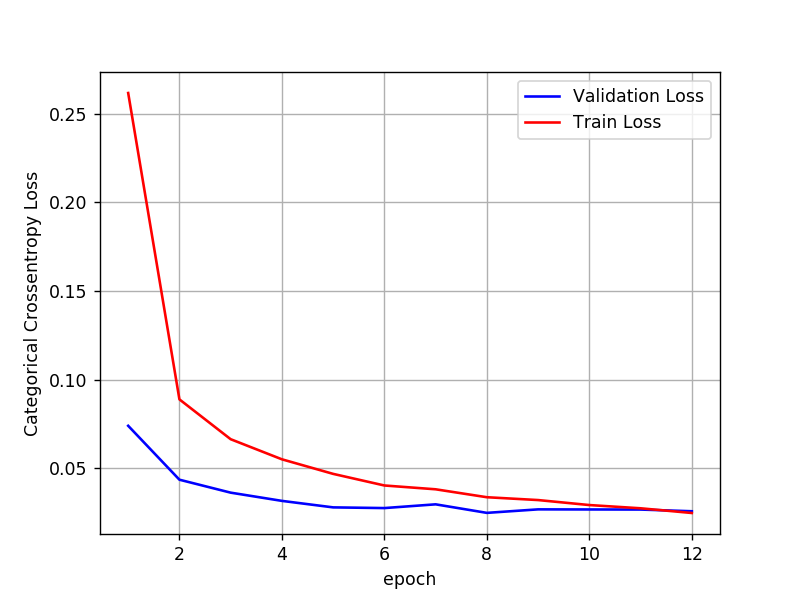

In [3]:
fig,ax = plt.subplots(1,1)
ax.set_xlabel('epoch') ; ax.set_ylabel('Categorical Crossentropy Loss')
# list of epoch numbers
x = list(range(1,epochs+1))
vy = history.history['val_loss']
ty = history.history['loss']
plt_dynamic(x, vy, ty, ax)

In [4]:
# Credits: https://github.com/keras-team/keras/blob/master/examples/mnist_cnn.py
from __future__ import print_function
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K


# Convnets With 3 * 3 Kernel and 7 Convolution Layer

In [5]:
epochs = 12
model = Sequential()
model.add(Conv2D(8, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=input_shape))
model.add(Conv2D(16, (3, 3), activation='relu'))
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(Dropout(0.25))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(Dropout(0.25))
model.add(Conv2D(256, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=keras.optimizers.Adadelta(),
              metrics=['accuracy'])

history_1 = model.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(x_test, y_test))
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Train on 60000 samples, validate on 10000 samples
Epoch 1/12
60000/60000 [==============================] - 1200s 20ms/step - loss: 0.3173 - accuracy: 0.9006 - val_loss: 0.0521 - val_accuracy: 0.9814
Epoch 2/12
60000/60000 [==============================] - 1217s 20ms/step - loss: 0.0853 - accuracy: 0.9754 - val_loss: 0.0347 - val_accuracy: 0.9889
Epoch 3/12
60000/60000 [==============================] - 1222s 20ms/step - loss: 0.0624 - accuracy: 0.9821 - val_loss: 0.0306 - val_accuracy: 0.9900
Epoch 4/12
60000/60000 [==============================] - 1027s 17ms/step - loss: 0.0517 - accuracy: 0.9848 - val_loss: 0.0388 - val_accuracy: 0.9877
Epoch 5/12
60000/60000 [==============================] - 823s 14ms/step - loss: 0.0439 - accuracy: 0.9870 - val_loss: 0.0317 - val_accuracy: 0.9892
Epoch 6/12
60000/60000 [==============================] - 787s 13ms/step - loss: 0.0378 - accuracy: 0.9887 - val_loss: 0.0251 - val_accuracy: 0.9909
Epoch 7/12
60000/60000 [============================

<IPython.core.display.Javascript object>


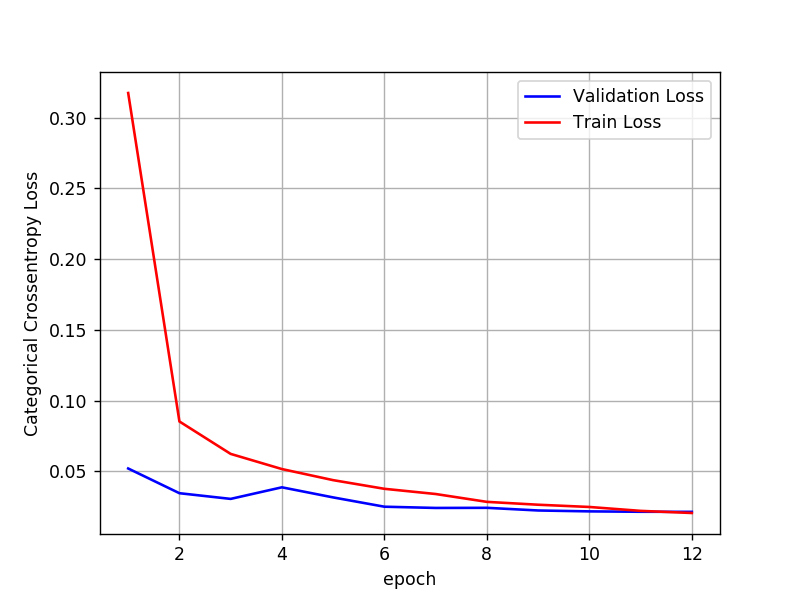

In [6]:
fig,ax = plt.subplots(1,1)
ax.set_xlabel('epoch') ; ax.set_ylabel('Categorical Crossentropy Loss')
# list of epoch numbers
x = list(range(1,epochs+1))
vy = history_1.history['val_loss']
ty = history_1.history['loss']
plt_dynamic(x, vy, ty, ax)

# Convnets With 5 * 5 Kernel and 5 Convolution Layer

In [7]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(5, 5),
                 activation='relu',
                 input_shape=input_shape))
model.add(Conv2D(64, (5, 5), activation='relu'))
model.add(Conv2D(128, (5, 5), activation='relu'))
model.add(Dropout(0.5))
model.add(Conv2D(256, (5, 5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=keras.optimizers.Adadelta(),
              metrics=['accuracy'])

history_2 = model.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(x_test, y_test))
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Train on 60000 samples, validate on 10000 samples
Epoch 1/12
60000/60000 [==============================] - 1271s 21ms/step - loss: 0.2850 - accuracy: 0.9113 - val_loss: 0.0411 - val_accuracy: 0.9866
Epoch 2/12
60000/60000 [==============================] - 1221s 20ms/step - loss: 0.0725 - accuracy: 0.9795 - val_loss: 0.0466 - val_accuracy: 0.9851
Epoch 3/12
60000/60000 [==============================] - 1282s 21ms/step - loss: 0.0502 - accuracy: 0.9856 - val_loss: 0.0230 - val_accuracy: 0.9934
Epoch 4/12
60000/60000 [==============================] - 1401s 23ms/step - loss: 0.0400 - accuracy: 0.9887 - val_loss: 0.0206 - val_accuracy: 0.9936
Epoch 5/12
60000/60000 [==============================] - 1239s 21ms/step - loss: 0.0342 - accuracy: 0.9903 - val_loss: 0.0194 - val_accuracy: 0.9942
Epoch 6/12
60000/60000 [==============================] - 1308s 22ms/step - loss: 0.0284 - accuracy: 0.9914 - val_loss: 0.0212 - val_accuracy: 0.9929
Epoch 7/12
60000/60000 [==========================

<IPython.core.display.Javascript object>


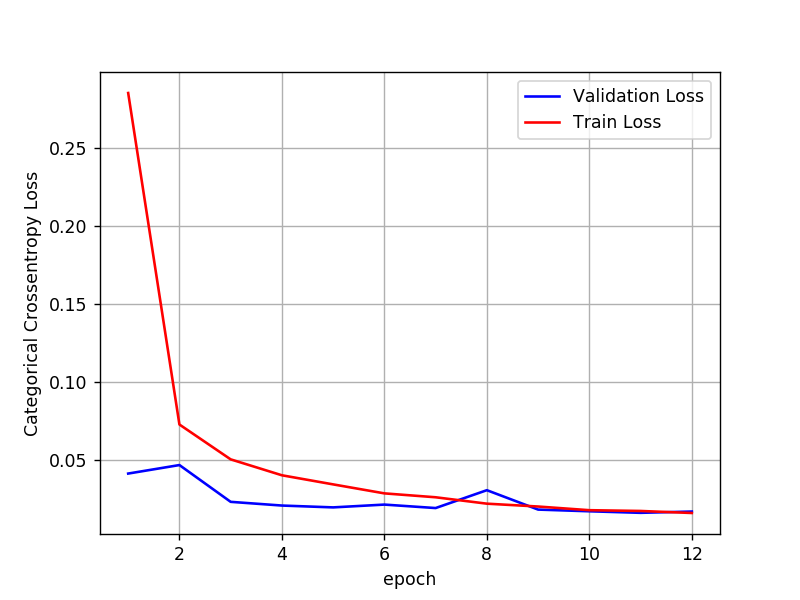

In [8]:
fig,ax = plt.subplots(1,1)
ax.set_xlabel('epoch') ; ax.set_ylabel('Categorical Crossentropy Loss')
# list of epoch numbers
x = list(range(1,epochs+1))
vy = history_2.history['val_loss']
ty = history_2.history['loss']
plt_dynamic(x, vy, ty, ax)

# Convnets With 7 * 7 Kernel and 3 Convolution Layer

In [9]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(7, 7),
                 activation='relu',
                 input_shape=input_shape))
model.add(Conv2D(64, (7, 7), activation='relu'))
model.add(Conv2D(128, (7, 7), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=keras.optimizers.Adadelta(),
              metrics=['accuracy'])

history_3 = model.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(x_test, y_test))
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Train on 60000 samples, validate on 10000 samples
Epoch 1/12
60000/60000 [==============================] - 797s 13ms/step - loss: 0.2683 - accuracy: 0.9173 - val_loss: 0.0662 - val_accuracy: 0.9799
Epoch 2/12
60000/60000 [==============================] - 792s 13ms/step - loss: 0.0664 - accuracy: 0.9810 - val_loss: 0.0342 - val_accuracy: 0.9890
Epoch 3/12
60000/60000 [==============================] - 779s 13ms/step - loss: 0.0470 - accuracy: 0.9861 - val_loss: 0.0238 - val_accuracy: 0.9921
Epoch 4/12
60000/60000 [==============================] - 784s 13ms/step - loss: 0.0365 - accuracy: 0.9898 - val_loss: 0.0220 - val_accuracy: 0.9929
Epoch 5/12
60000/60000 [==============================] - 760s 13ms/step - loss: 0.0293 - accuracy: 0.9913 - val_loss: 0.0233 - val_accuracy: 0.9930
Epoch 6/12
60000/60000 [==============================] - 753s 13ms/step - loss: 0.0262 - accuracy: 0.9923 - val_loss: 0.0216 - val_accuracy: 0.9935
Epoch 7/12
60000/60000 [==============================] 

<IPython.core.display.Javascript object>


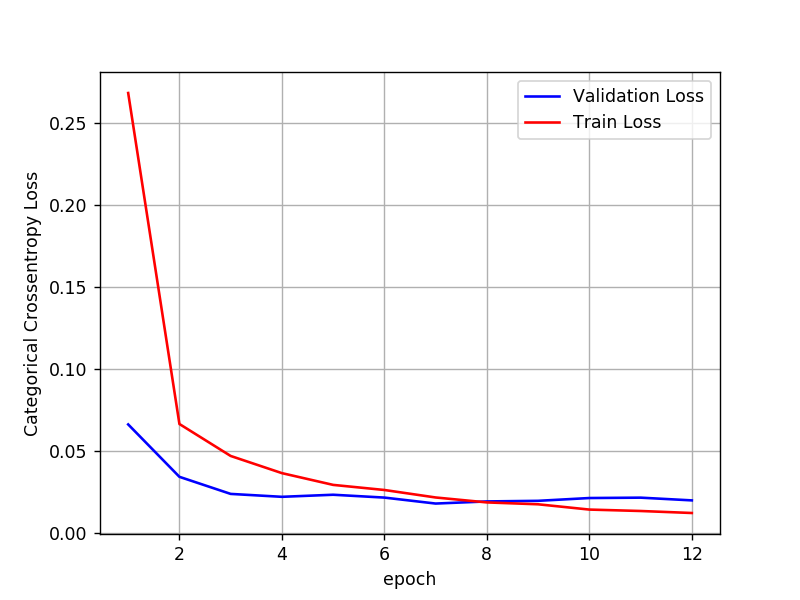

In [10]:
fig,ax = plt.subplots(1,1)
ax.set_xlabel('epoch') ; ax.set_ylabel('Categorical Crossentropy Loss')
# list of epoch numbers
x = list(range(1,epochs+1))
vy = history_3.history['val_loss']
ty = history_3.history['loss']
plt_dynamic(x, vy, ty, ax)

<h1>Conclusions</h1>

In [11]:
# Please compare all your models using Prettytable library
from prettytable import PrettyTable
x = PrettyTable()
x.field_names = ["Kernel and Layers", "Categorical Crossentropy Loss" ,"Test accuracy" ]
x.add_row(["Convnets With 3 * 3 Kernel and 7 Convolution Layer ",0.021 ,"99.37%"])
x.add_row(["Convnets With 5 * 5 Kernel and 5 Convolution Layer", 0.016 ,"99.51%" ])
x.add_row(["Convnets With 7 * 7 Kernel and 3 Convolution Layer",0.019 , " 99.48%"])
print(x)

+-----------------------------------------------------+-------------------------------+---------------+
|                  Kernel and Layera                  | Categorical Crossentropy Loss | Test accuracy |
+-----------------------------------------------------+-------------------------------+---------------+
| Convnets With 3 * 3 Kernel and 7 Convolution Layer  |             0.021             |     99.37%    |
|  Convnets With 5 * 5 Kernel and 5 Convolution Layer |             0.016             |     99.51%    |
|  Convnets With 7 * 7 Kernel and 3 Convolution Layer |             0.019             |     99.48%    |
+-----------------------------------------------------+-------------------------------+---------------+
